In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer



In [2]:
df = pd.read_csv("Q1heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


#Preprocessing

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.shape

(303, 14)

In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

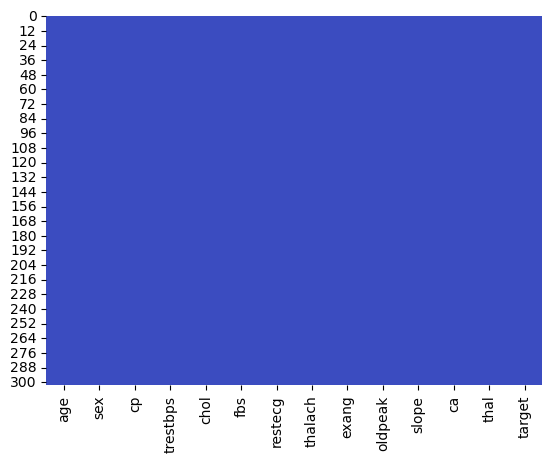

In [9]:

sns.heatmap(df.isnull(), cbar=False, cmap="coolwarm")
plt.show()


In [10]:
df.duplicated().value_counts

<bound method IndexOpsMixin.value_counts of 0      False
1      False
2      False
3      False
4      False
       ...  
298    False
299    False
300    False
301    False
302    False
Length: 303, dtype: bool>

In [11]:
num_cols = df.select_dtypes(include=['number']).columns

imputer = SimpleImputer(strategy='mean')

df[num_cols] = imputer.fit_transform(df[num_cols])


In [12]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1.0
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1.0
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1.0
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1.0
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57.0,0.0,0.0,140.0,241.0,0.0,1.0,123.0,1.0,0.2,1.0,0.0,3.0,0.0
299,45.0,1.0,3.0,110.0,264.0,0.0,1.0,132.0,0.0,1.2,1.0,0.0,3.0,0.0
300,68.0,1.0,0.0,144.0,193.0,1.0,1.0,141.0,0.0,3.4,1.0,2.0,3.0,0.0
301,57.0,1.0,0.0,130.0,131.0,0.0,1.0,115.0,1.0,1.2,1.0,1.0,3.0,0.0


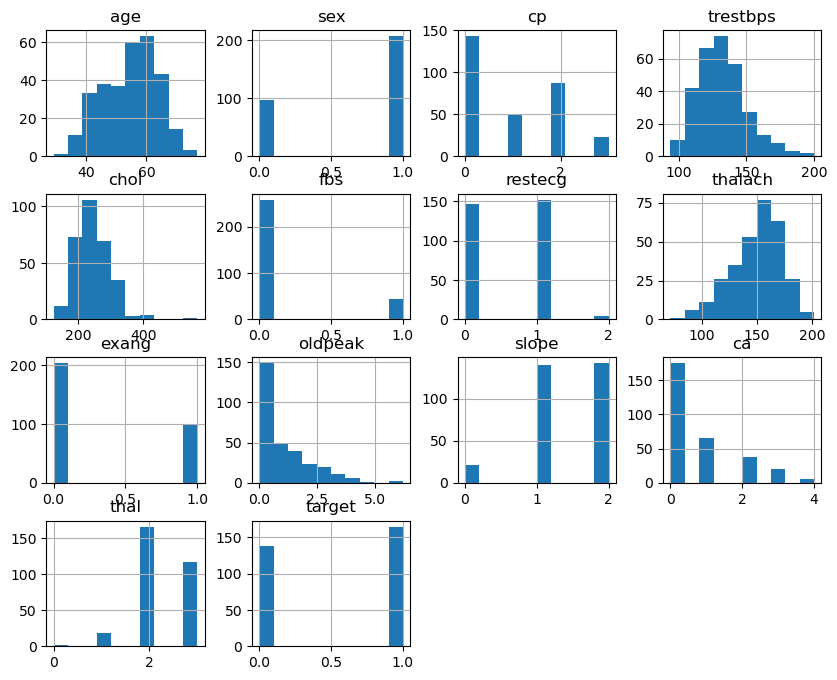

In [13]:
df.hist(figsize=(10,8))
plt.show()

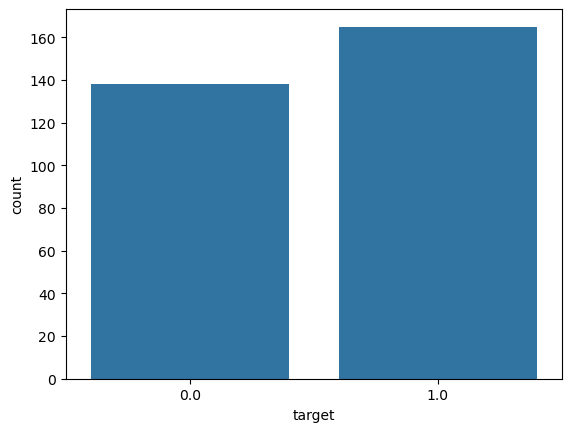

In [14]:
sns.countplot(x="target", data=df)
plt.show()

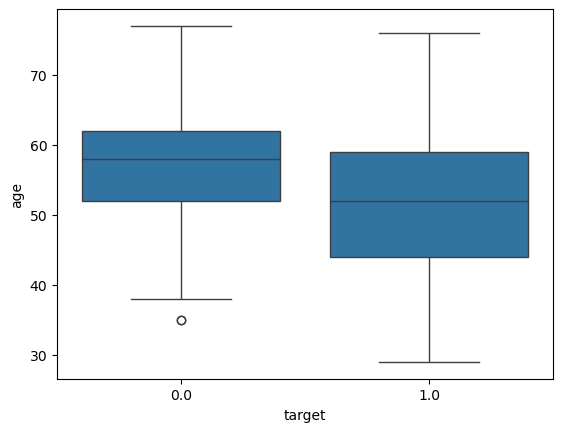

In [21]:

sns.boxplot(x=df.columns[-1], y=df['age'], data=df)
plt.show()


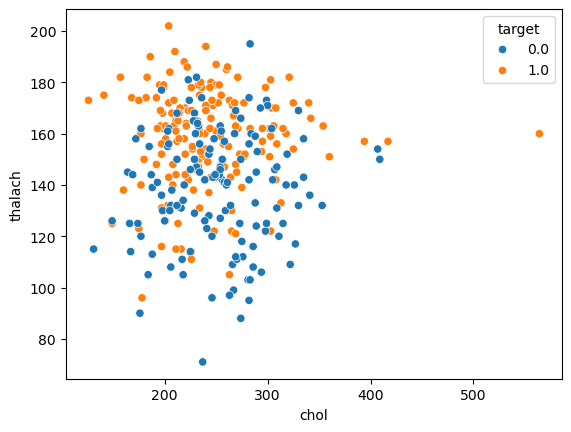

In [18]:

sns.scatterplot(x=df['chol'], y=df['thalach'], hue=df[df.columns[-1]])
plt.show()


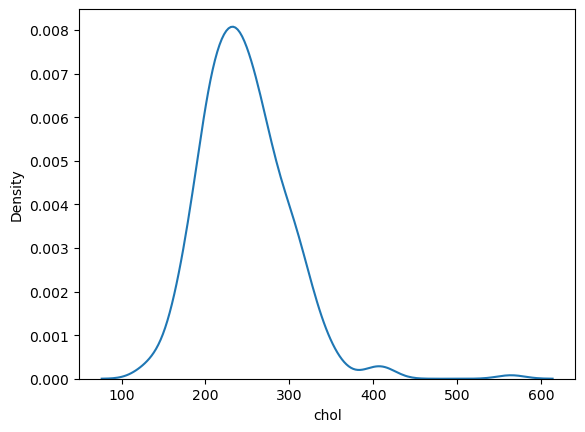

In [23]:
sns.kdeplot(df['chol'])
plt.show()


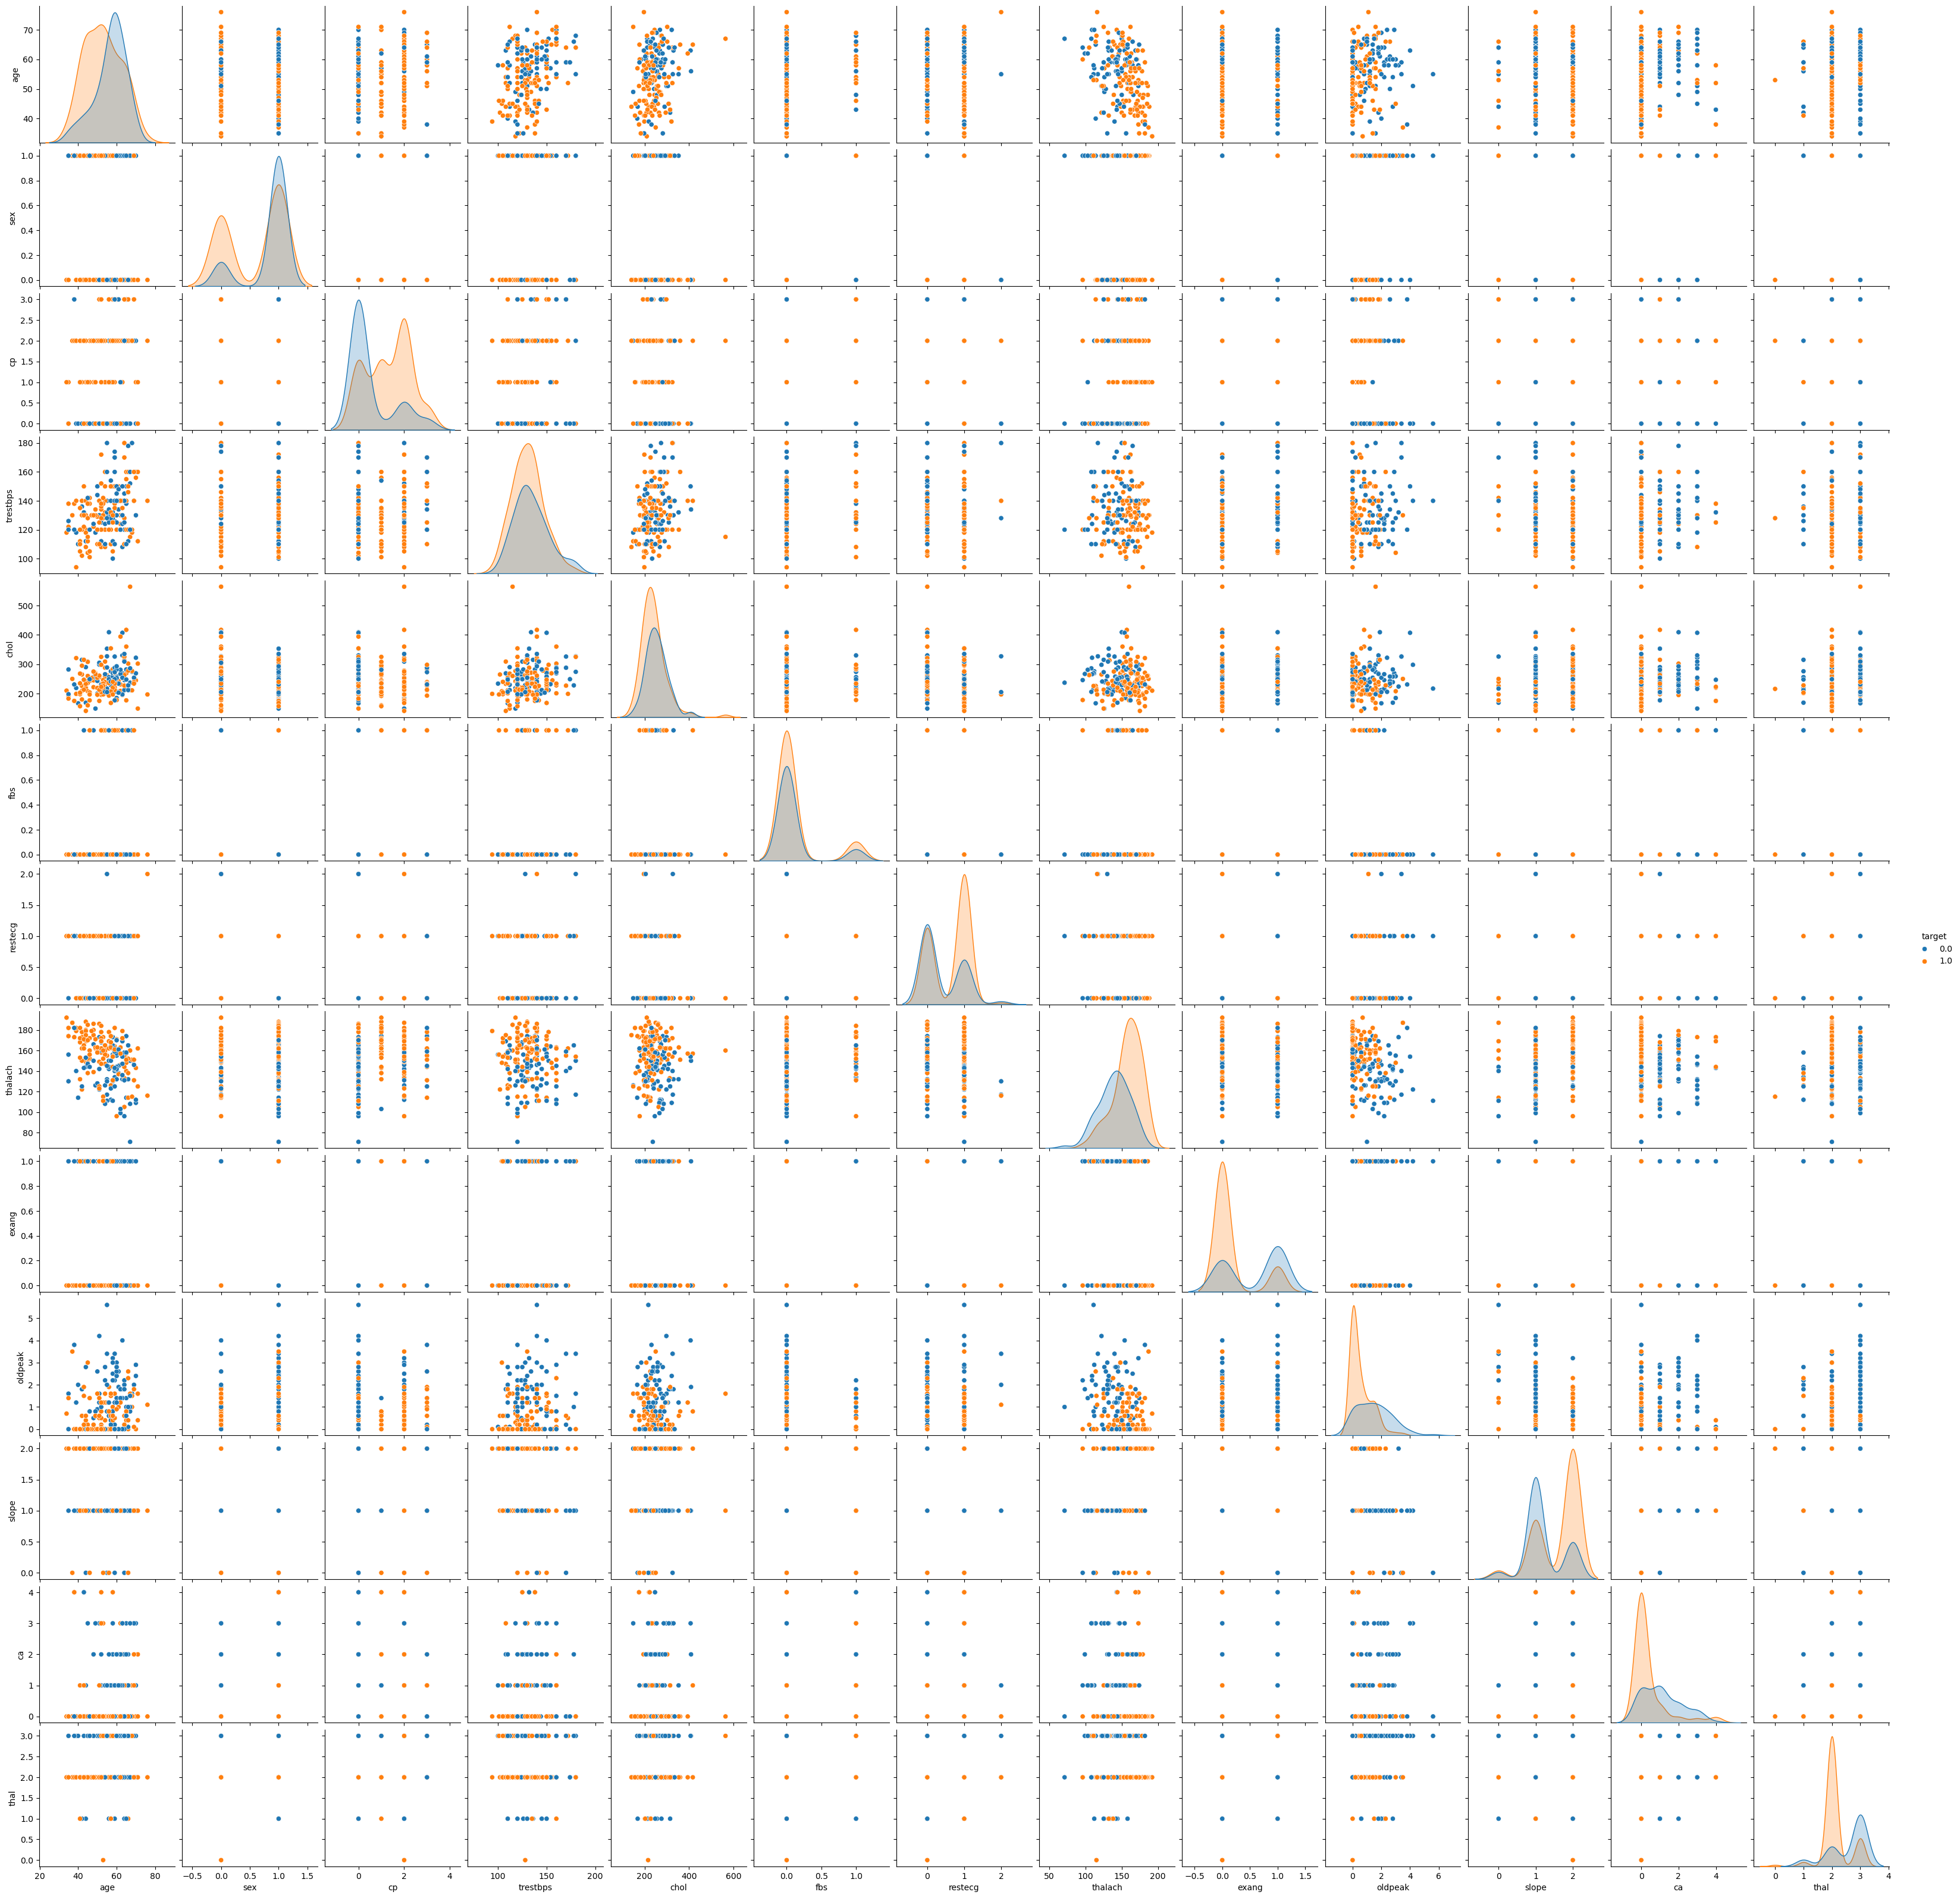

In [67]:

sns.pairplot(df.sample(200), hue=df.columns[-1])
plt.show()


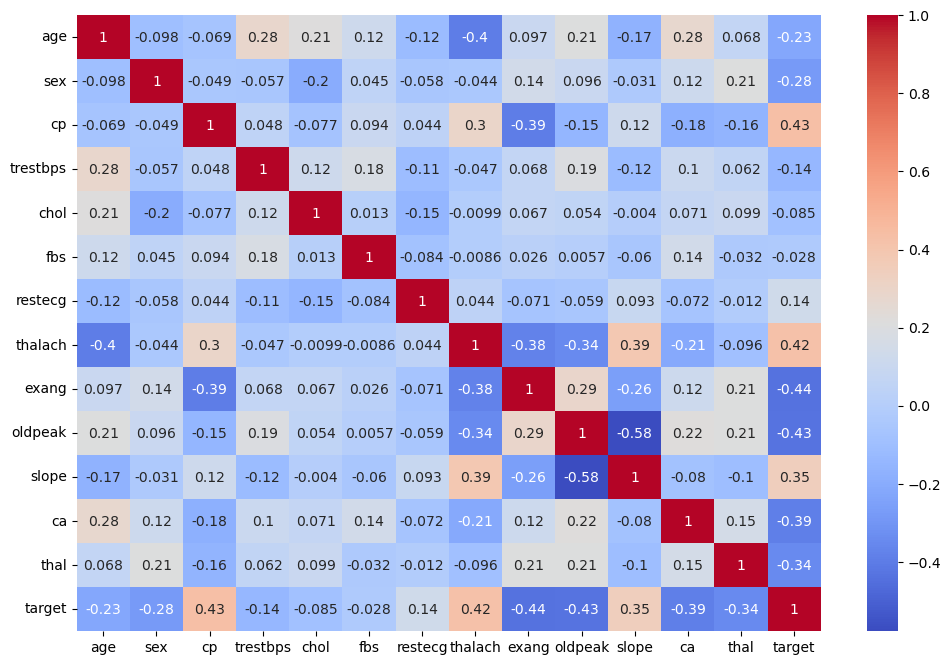

In [25]:

plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


In [27]:
#Feature Selection


X = df.drop(["target"],axis=1)
y = df['target']

In [28]:
#split data

X_train, X_test,y_train,y_test = train_test_split(X,y, train_size = 0.80,random_state=42)

In [31]:
#Feature Scaling 

scaler  = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test  = scaler.fit_transform(X_test)




In [37]:
# Model Implemantation
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [40]:
#Logistic Regression model ---
lr = LogisticRegression()

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)






In [60]:
#Evalutions ----

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("classification_report :", classification_report(y_test, lr_pred))
print("confusion_matrix:", confusion_matrix(y_test, lr_pred))

print("precision_score:", precision_score(y_test, lr_pred))
print("recall_score:", recall_score(y_test, lr_pred))
print("f1_score:", f1_score(y_test, lr_pred))


Accuracy : 0.8852459016393442
classification_report :               precision    recall  f1-score   support

         0.0       0.89      0.86      0.88        29
         1.0       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61

confusion_matrix: [[25  4]
 [ 3 29]]
precision_score: 0.8787878787878788
recall_score: 0.90625
f1_score: 0.8923076923076924


In [45]:
#KNeighborsClassifier Model
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("Accuracy :", accuracy_score(y_test, knn_pred))


Accuracy : 0.9016393442622951


In [61]:
print("Accuracy :", accuracy_score(y_test, knn_pred))
print("classification_report :", classification_report(y_test, knn_pred))
print("confusion_matrix:", confusion_matrix(y_test, knn_pred))

print("precision_score:", precision_score(y_test, knn_pred))
print("recall_score:", recall_score(y_test, knn_pred))
print("f1_score:", f1_score(y_test, knn_pred))


Accuracy : 0.9016393442622951
classification_report :               precision    recall  f1-score   support

         0.0       0.90      0.90      0.90        29
         1.0       0.91      0.91      0.91        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61

confusion_matrix: [[26  3]
 [ 3 29]]
precision_score: 0.90625
recall_score: 0.90625
f1_score: 0.90625


In [62]:
#Decision tree Model
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("classification_report :", classification_report(y_test, dt_pred))
print("confusion_matrix:", confusion_matrix(y_test, dt_pred))

print("precision_score:", precision_score(y_test, dt_pred))
print("recall_score:", recall_score(y_test, dt_pred))
print("f1_score:", f1_score(y_test, dt_pred))


Accuracy : 0.819672131147541
classification_report :               precision    recall  f1-score   support

         0.0       0.76      0.90      0.83        29
         1.0       0.89      0.75      0.81        32

    accuracy                           0.82        61
   macro avg       0.83      0.82      0.82        61
weighted avg       0.83      0.82      0.82        61

confusion_matrix: [[26  3]
 [ 8 24]]
precision_score: 0.8888888888888888
recall_score: 0.75
f1_score: 0.8135593220338984


In [63]:
#Random Forest
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("classification_report :", classification_report(y_test, rf_pred))
print("confusion_matrix:", confusion_matrix(y_test, rf_pred))

print("precision_score:", precision_score(y_test, rf_pred))
print("recall_score:", recall_score(y_test, rf_pred))
print("f1_score:", f1_score(y_test, rf_pred))


Accuracy : 0.8524590163934426
classification_report :               precision    recall  f1-score   support

         0.0       0.88      0.79      0.84        29
         1.0       0.83      0.91      0.87        32

    accuracy                           0.85        61
   macro avg       0.86      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61

confusion_matrix: [[23  6]
 [ 3 29]]
precision_score: 0.8285714285714286
recall_score: 0.90625
f1_score: 0.8656716417910447


In [64]:
#Support Vector Model --
svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("Accuracy :", accuracy_score(y_test, svm_pred))
print("classification_report :", classification_report(y_test, svm_pred))
print("confusion_matrix:", confusion_matrix(y_test, svm_pred))

print("precision_score:", precision_score(y_test, svm_pred))
print("recall_score:", recall_score(y_test, svm_pred))
print("f1_score:", f1_score(y_test, svm_pred))



Accuracy : 0.8688524590163934
classification_report :               precision    recall  f1-score   support

         0.0       0.89      0.83      0.86        29
         1.0       0.85      0.91      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

confusion_matrix: [[24  5]
 [ 3 29]]
precision_score: 0.8529411764705882
recall_score: 0.90625
f1_score: 0.8787878787878788


In [65]:
#Conclusion
print("Random Forest and SVM performed well.")
print("Feature scaling improved performance.")
print("Medical parameters influenced heart disease prediction.")


Random Forest and SVM performed well.
Feature scaling improved performance.
Medical parameters influenced heart disease prediction.
